In [3]:
import torch
import torch.nn as nn

from hello.deepWorld.models.spvgg import SpVGG,vgg_prepro
from hello.deepWorld.models.spresnet import SpResNet,resNet_prepro
from hello.deepWorld.models.sprecurrent import SpRecurrent,recurrent_to_spectr_prepro
import hello.deepWorld.trainingTools as trainingTools

from tqdm import tqdm

import hello.deepWorld.utils as deepUtils


import hello.dataWorld.dataset.pangramDataLoaders as panDL
from hello.dataWorld.audioTools import printAudio
from matplotlib.pyplot import imshow
from hello.dataWorld.dataset.pangramDataLoaders import pad_collate

import os
import json

In [15]:
params=deepUtils.Params("./train_configs/pangram_spvgg.json")
paramsPrint=json.load(open("./train_configs/pangram_spvgg.json"))

device = deepUtils.get_best_device()

model=SpVGG(
                    num_classes=8
                )

train_loader,_=panDL.get_SpeakerSignalDataLoader(files_dir=params.data_dir+"/train",signalType="png",
                                    prepro_func=vgg_prepro,batch_size=params.batch_size,num_workers=params.num_workers,collate_fn=pad_collate)
val_loader,_=panDL.get_SpeakerSignalDataLoader(files_dir=params.data_dir+"/val",signalType="png",
                                    prepro_func=vgg_prepro,batch_size=params.batch_size,num_workers=params.num_workers,collate_fn=pad_collate)

loss_fn = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(model.parameters(), lr=params.lr, weight_decay=params.weight_decay)

if params.scheduler:
    pass
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 25, gamma=0.1)
else:
    scheduler = None

print(f"Parameters used:\n {paramsPrint}")
print(f"Model:\n {model}")
print(f"\nDevice: {device}")
print(f"\nOptimizer: {optimizer}")

print("Initial evaluation:\n")
deepUtils.evaluate(model=model,device=device,test_loader=val_loader,loss_fn=loss_fn)

# #trainingTools.train_and_evaluate_accuracy(model,train_loader=train_loader,val_loader=val_loader,
#                     optimizer=optimizer,device=device,loss_fn=loss_fn,scheduler=scheduler,params=params)

Using cache found in C:\Users\emman/.cache\torch\hub\pytorch_vision_v0.10.0
  0%|          | 0/19 [00:00<?, ?it/s]

Parameters used:
 {'dataset_name': 'pangram', 'data_dir': 'C:/Users/emman/Desktop/Tesi/AI voice cloning/codice/data_driven_ai_voice_cloning/data/data_flat/sp_img_dataset_mq_trim25_nftt8800_w128_h128', 'pretrained': False, 'scheduler': True, 'model': 'sresnet v1.0', 'batch_size': 8, 'num_workers': 2, 'epochs': 5, 'lr': 0.0001, 'weight_decay': 0.001, 'checkpoint_dir': 'C:/Users/emman/Desktop/Tesi/AI voice cloning/codice/data_driven_ai_voice_cloning/deep_experiments/runs/models_ckpt/spvgg_v1.1', 'logdir': 'C:/Users/emman/Desktop/Tesi/AI voice cloning/codice/data_driven_ai_voice_cloning/deep_experiments/runs/models_log/spvgg_v1.1'}
Model:
 SpVGG(
  (model): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(64, 

100%|██████████| 19/19 [02:13<00:00,  7.02s/it, loss=2.118, acc=8.16]


(8.16326530612245, 2.1177610598112406)

Computing optimal learning rate:  33%|███▎      | 33/100 [1:28:50<3:00:22, 161.53s/it]


Stopping early, the loss has diverged
Resetting model and optimizer


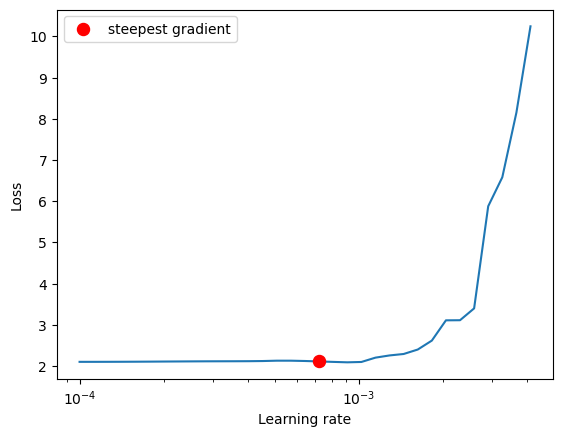

<AxesSubplot:xlabel='Learning rate', ylabel='Loss'>

In [17]:
from monai.optimizers.lr_finder import LearningRateFinder
optimizer = torch.optim.Adam(model.parameters(), lr=params.lr, weight_decay=params.weight_decay)
lrf=LearningRateFinder(model=model,optimizer=optimizer,criterion=loss_fn,device=device)

lrf.range_test(train_loader=train_loader,val_loader=val_loader)

lrf.plot()


In [21]:
print(lrf.get_steepest_gradient())

(0.0007220809018385464, 2.1119738996706494)
